##### 1. Load dataset and EDA

#### Load Dataset

In [ ]:
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, RobertaTokenizerFast
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords

import nltk
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from wordcloud import WordCloud
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# Load dataset
dataset = load_dataset("tweet_eval", "sentiment")

# Konversi ke pandas untuk preprocessing lebih mudah
df = pd.DataFrame(dataset['train'])

# Mapping label: 0 = negative, 1 = neutral, 2 = positive
label_map = {0: "negative", 1: "neutral", 2: "positive"}
df["label_text"] = df["label"].map(label_map)

df.head()

,text,label,label_text
0,"""QT @user In the original draft of the 7th boo...",2,positive
1,"""Ben Smith / Smith (concussion) remains out of...",1,neutral
2,Sorry bout the stream last night I crashed out...,1,neutral
3,Chase Headley's RBI double in the 8th inning o...,1,neutral
4,@user Alciato: Bee will invest 150 million in ...,2,positive


#### EDA

In [ ]:
df.shape

(45615, 3)

C:\Users\User\AppData\Local\Temp\ipykernel_10736\760238489.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_text", y="text_len", data=df, palette="Set3")


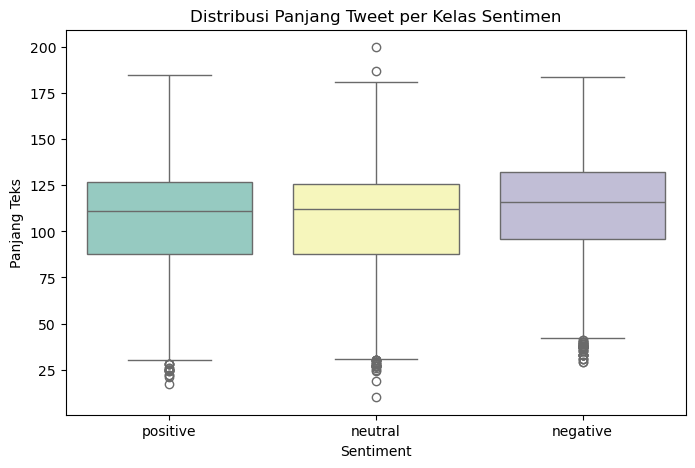

count    45615.000000
mean       106.932851
std         26.251517
min         10.000000
25%         89.000000
50%        113.000000
75%        128.000000
max        200.000000
Name: text_len, dtype: float64

In [ ]:
# Tambahkan kolom panjang teks
df["text_len"] = df["text"].apply(len)

# Boxplot panjang teks per kelas
plt.figure(figsize=(8,5))
sns.boxplot(x="label_text", y="text_len", data=df, palette="Set3")
plt.title("Distribusi Panjang Tweet per Kelas Sentimen")
plt.xlabel("Sentiment")
plt.ylabel("Panjang Teks")
plt.show()

# Statistik panjang teks
df["text_len"].describe()


C:\Users\User\AppData\Local\Temp\ipykernel_15432\676833191.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label_text", data=df, palette="Set2")


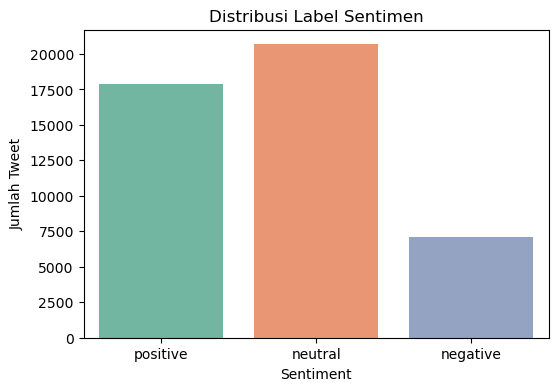

label_text
neutral     20673
positive    17849
negative     7093
Name: count, dtype: int64

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x="label_text", data=df, palette="Set2")
plt.title("Distribusi Label Sentimen")
plt.xlabel("Sentiment")
plt.ylabel("Jumlah Tweet")
plt.show()

# Jumlah masing-masing label
df["label_text"].value_counts()


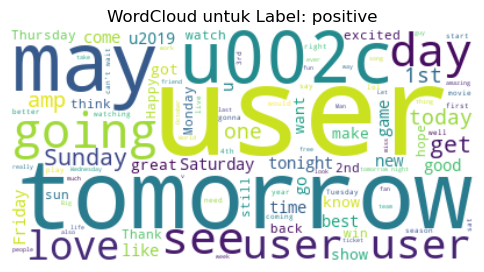

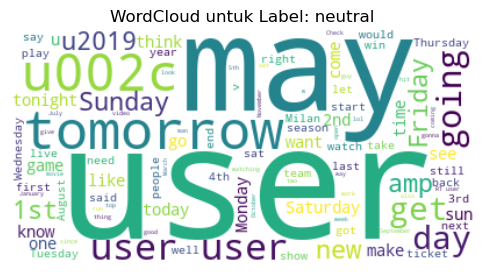

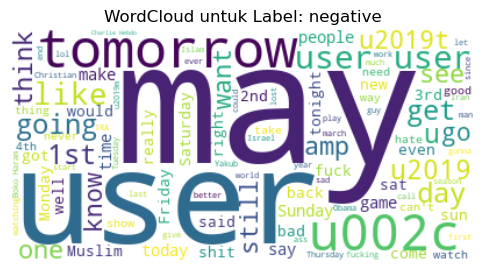

In [ ]:
stop_words = set(stopwords.words('english'))

def generate_wordcloud(label):
    text = " ".join(df[df["label_text"] == label]["text"].values)
    wordcloud = WordCloud(stopwords=stop_words, background_color='white', max_words=100).generate(text)
    plt.figure(figsize=(6,4))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud untuk Label: {label}")
    plt.show()

generate_wordcloud("positive")
generate_wordcloud("neutral")
generate_wordcloud("negative")


##### 2. Preprocessing, Splitting, and balancing data

In [ ]:
import re
import emoji
import pandas as pd

def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www.\S+", "", text)                  # Hapus URL
    text = re.sub(r"@\w+", "", text)                             # Hapus mention
    text = re.sub(r"#\w+", "", text)                             # Hapus hashtag
    text = emoji.replace_emoji(text, replace='')                 # Hapus emoji
    text = re.sub(r"[^A-Za-z0-9\s\.\,\!\?]", "", text)           # Hapus simbol aneh
    text = re.sub(r"\s+", " ", text)                             # Hapus spasi berlebih
    return text.strip()

# Contoh pemrosesan seluruh kolom
df["text"] = df["text"].apply(clean_text)

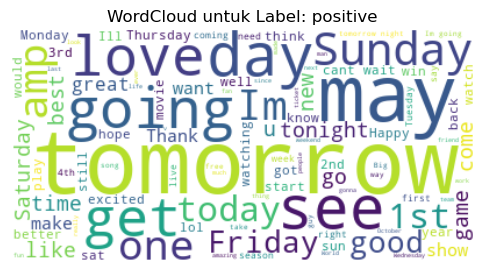

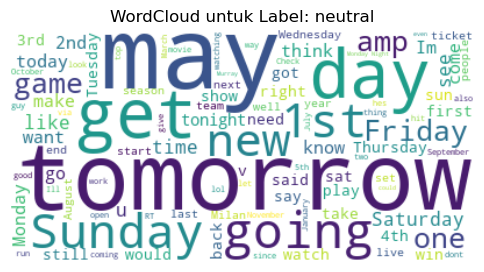

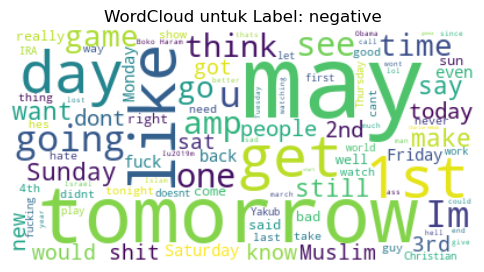

In [87]:
stop_words = set(stopwords.words('english'))

def generate_wordcloud(label):
    text = " ".join(df[df["label_text"] == label]["text"].values)
    wordcloud = WordCloud(stopwords=stop_words, background_color='white', max_words=100).generate(text)
    plt.figure(figsize=(6,4))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud untuk Label: {label}")
    plt.show()

generate_wordcloud("positive")
generate_wordcloud("neutral")
generate_wordcloud("negative")

In [ ]:
# Split train, val, test
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.1, stratify=train_df["label"], random_state=42)

In [89]:
train_df['label_text'].value_counts()

label_text
neutral     14885
positive    12851
negative     5106
Name: count, dtype: int64

In [90]:
test_df['label_text'].value_counts()

label_text
neutral     4134
positive    3570
negative    1419
Name: count, dtype: int64

In [91]:
val_df['label_text'].value_counts()

label_text
neutral     1654
positive    1428
negative     568
Name: count, dtype: int64

#### Oversampling

In [ ]:
X_over = train_df["text"].values.reshape(-1, 1)
y_over = train_df["label"]

ros = RandomOverSampler(random_state=42)
X_over, y_over = ros.fit_resample(X_over, y_over)

c:\Users\User\miniconda3\envs\myenv\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\User\miniconda3\envs\myenv\lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
c:\Users\User\miniconda3\envs\myenv\lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [ ]:
train_over_df = pd.DataFrame({
    "text": X_over.flatten(),
    "label": y_over
})
train_over_df["label_text"] = train_over_df["label"].map(label_map)

#### Undersampling

In [ ]:
# ======= Under Sampling =======
X_under = train_df["text"].values.reshape(-1, 1)
y_under = train_df["label"]

rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_under, y_under)

c:\Users\User\miniconda3\envs\myenv\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\User\miniconda3\envs\myenv\lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
c:\Users\User\miniconda3\envs\myenv\lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [ ]:
train_under_df = pd.DataFrame({
    "text": X_under.flatten(),
    "label": y_under
})
train_under_df["label_text"] = train_under_df["label"].map(label_map)

#### Results Balancing Using (ROS and RUS) and Train data without balancing

In [14]:
train_over_df['label_text'].value_counts()

label_text
positive    14885
negative    14885
neutral     14885
Name: count, dtype: int64

In [15]:
train_under_df['label_text'].value_counts()

label_text
negative    5106
neutral     5106
positive    5106
Name: count, dtype: int64

In [103]:
train_df['label_text'].value_counts()

label_text
neutral     14885
positive    12851
negative     5106
Name: count, dtype: int64

#### 1. Roberta model

##### Tokenisasi & persipan dataset (roberta)

In [27]:
# Gunakan tokenizer dari roberta-base
tokenizer = RobertaTokenizerFast.from_pretrained('roberta-base')

In [28]:
def tokenize_function(example):
    return tokenizer(example["text"], truncation=True, padding='max_length', max_length=128)

##### Without balancing dataset

In [96]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df[['text', 'label']])
val_ds   = Dataset.from_pandas(val_df[['text', 'label']])
test_ds  = Dataset.from_pandas(test_df[['text', 'label']])

# Tokenize
train_ds = train_ds.map(tokenize_function, batched=True)
val_ds   = val_ds.map(tokenize_function, batched=True)
test_ds  = test_ds.map(tokenize_function, batched=True)

# Set format PyTorch
train_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])


Map:   0%|          | 0/32842 [00:00<?, ? examples/s]

Map:   0%|          | 0/3650 [00:00<?, ? examples/s]

Map:   0%|          | 0/9123 [00:00<?, ? examples/s]

##### Dataset with balancing

Oversampling

In [97]:
# Ulangi langkah yang sama, tapi pakai train_over_df atau train_under_df
train_over_ds = Dataset.from_pandas(train_over_df[['text', 'label']])
train_over_ds = train_over_ds.map(tokenize_function, batched=True)
train_over_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])


Map:   0%|          | 0/44655 [00:00<?, ? examples/s]

Undersampling

In [98]:
# Ulangi langkah yang sama, tapi pakai train_over_df atau train_under_df
train_under_df = Dataset.from_pandas(train_under_df[['text', 'label']])
train_under_df = train_under_df.map(tokenize_function, batched=True)
train_under_df.set_format("torch", columns=["input_ids", "attention_mask", "label"])


Map:   0%|          | 0/15318 [00:00<?, ? examples/s]

##### Fine-tuning roberta model

In [99]:
from sklearn.metrics import classification_report, accuracy_score, f1_score
from transformers import RobertaForSequenceClassification, Trainer, TrainingArguments

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {
        'accuracy': acc,
        'f1': f1
    }


In [100]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    fp16=True,
    logging_dir='./logs',
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)


without balancing dataset

In [24]:
# model_A = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=3)

# trainer_A = Trainer(
#     model=model_A,
#     args=training_args,
#     train_dataset=train_ds,
#     eval_dataset=val_ds,
#     compute_metrics=compute_metrics
# )

# trainer_A.train()


with oversampling dataset

In [25]:
# model_B = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=3)

# trainer_B = Trainer(
#     model=model_B,
#     args=training_args,
#     train_dataset=train_over_ds,  
#     eval_dataset=val_ds,
#     compute_metrics=compute_metrics
# )

# trainer_B.train()


with undersampling dataset

In [26]:
# model_C = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=3)

# trainer_C = Trainer(
#     model=model_C,
#     args=training_args,
#     train_dataset=train_under_df, 
#     eval_dataset=val_ds,
#     compute_metrics=compute_metrics
# )   

##### Evaluasi RoBERTa model

In [101]:
def evaluate_model(model_path, model_name):
    model = RobertaForSequenceClassification.from_pretrained(model_path)

    eval_args = TrainingArguments(
        output_dir=f"./temp_eval_{model_name}",
        per_device_eval_batch_size=64,
        do_train=False,
        do_eval=True,
    )

    def compute_metrics(pred):
        y_true = pred.label_ids
        y_pred = np.argmax(pred.predictions, axis=1)
        return {
            "accuracy": accuracy_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred, average="weighted")
        }
    
    trainer = Trainer(
        model=model,
        args=eval_args,
        compute_metrics=compute_metrics
    )

    results = trainer.evaluate(test_ds)

    # Print classification report
    preds = trainer.predict(test_ds)
    y_pred = np.argmax(preds.predictions, axis=1)
    y_true = preds.label_ids

    print(f"\n📘 Evaluation for {model_name}")
    print("Accuracy:", results["eval_accuracy"])
    print("F1 Score:", results["eval_f1"])
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=["Negative", "Neutral", "Positive"]))

    return results

In [18]:
from transformers import RobertaForSequenceClassification

# Load ketiga model
model_A = RobertaForSequenceClassification.from_pretrained("./results/original/checkpoint-4106", use_safetensors=True)
model_B = RobertaForSequenceClassification.from_pretrained("./results/over_sampling/checkpoint-5582", use_safetensors=True)
model_C = RobertaForSequenceClassification.from_pretrained("./results/under_sampling/checkpoint-1914", use_safetensors=True)

In [29]:
evaluate_model("./results/original/checkpoint-4106", "Model A (Original)")
evaluate_model("./results/over_sampling/checkpoint-5582", "Model B (Over sampling)")
evaluate_model("./results/under_sampling/checkpoint-1914", "Model C (Under sampling)")



📘 Evaluation for Model A (Original)
Accuracy: 0.724871204647594
F1 Score: 0.7244997204701614
Classification Report:
              precision    recall  f1-score   support

    Negative       0.63      0.65      0.64      1419
     Neutral       0.73      0.69      0.71      4134
    Positive       0.76      0.79      0.77      3570

    accuracy                           0.72      9123
   macro avg       0.71      0.71      0.71      9123
weighted avg       0.72      0.72      0.72      9123




📘 Evaluation for Model B (Over sampling)
Accuracy: 0.7181848076290693
F1 Score: 0.7185839334690437
Classification Report:
              precision    recall  f1-score   support

    Negative       0.60      0.68      0.64      1419
     Neutral       0.73      0.68      0.71      4134
    Positive       0.76      0.78      0.77      3570

    accuracy                           0.72      9123
   macro avg       0.70      0.71      0.70      9123
weighted avg       0.72      0.72      0.72      9123




📘 Evaluation for Model C (Under sampling)
Accuracy: 0.6910007672914611
F1 Score: 0.6926472202989326
Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      0.83      0.63      1419
     Neutral       0.76      0.59      0.66      4134
    Positive       0.75      0.76      0.76      3570

    accuracy                           0.69      9123
   macro avg       0.67      0.72      0.68      9123
weighted avg       0.72      0.69      0.69      9123



{'eval_loss': 0.7262516021728516,
 'eval_model_preparation_time': 0.0035,
 'eval_accuracy': 0.6910007672914611,
 'eval_f1': 0.6926472202989326,
 'eval_runtime': 574.8041,
 'eval_samples_per_second': 15.871,
 'eval_steps_per_second': 0.249}

karena Model A (tanpa balancing) memiliki performa terbaik, untuk model roberta saya menggunakan model A

In [35]:
from transformers import Trainer, TrainingArguments

eval_args = TrainingArguments(
    output_dir="./temp_eval_A",
    per_device_eval_batch_size=64,
    do_train=False,
    do_eval=True,
)

trainer_A = Trainer(
    model=model_A,
    args=eval_args
)

# Predict test set
predictions_A = trainer_A.predict(test_ds)
y_pred_A = np.argmax(predictions_A.predictions, axis=1)


#### 4. VADER model

In [107]:
analyzer = SentimentIntensityAnalyzer()
from sklearn.metrics import classification_report

def classify_vader(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'
    
# Terapkan ke data uji
test_df['vader_pred_default'] = test_df['text'].apply(classify_vader)

# Laporan klasifikasi
print("Evaluasi VADER dengan threshold default:")
print(classification_report(test_df['label_text'],test_df['vader_pred_default']))

Evaluasi VADER dengan threshold default:
              precision    recall  f1-score   support

    negative       0.39      0.58      0.46      1419
     neutral       0.64      0.40      0.49      4134
    positive       0.56      0.69      0.62      3570

    accuracy                           0.54      9123
   macro avg       0.53      0.56      0.52      9123
weighted avg       0.57      0.54      0.54      9123



In [ ]:
def vader_predict(texts, th_pos=0.05, th_neg=-0.05):
    preds = []
    for text in texts:
        score = analyzer.polarity_scores(text)["compound"]
        if score >= th_pos:
            preds.append(2)  # positive
        elif score <= th_neg:
            preds.append(0)  # negative
        else:
            preds.append(1)  # neutral
    return preds

best_f1 = 0
best_threshold = (0.05, -0.05)

# Uji threshold dari 0.01 hingga 0.5
thresholds = np.arange(0.01, 0.5, 0.01)

for th in thresholds:
    preds = vader_predict(test_df["text"], th_pos=th, th_neg=-th)
    f1 = f1_score(test_df["label"], preds, average="weighted")
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = (th, -th)

print("✅ Best F1-score:", best_f1)
print("✅ Best thresholds (pos, neg):", best_threshold)

✅ Best F1-score: 0.5876703559815111
✅ Best thresholds (pos, neg): (np.float64(0.41000000000000003), np.float64(-0.41000000000000003))


In [82]:
final_vader_preds = vader_predict(test_df["text"], 
                                   th_pos=best_threshold[0], 
                                   th_neg=best_threshold[1])

from sklearn.metrics import classification_report
print("📘 Classification Report (VADER - optimized threshold):")
print(classification_report(test_df["label"], final_vader_preds, target_names=["Negative", "Neutral", "Positive"]))


📘 Classification Report (VADER - optimized threshold):
              precision    recall  f1-score   support

    Negative       0.49      0.38      0.43      1419
     Neutral       0.58      0.68      0.62      4134
    Positive       0.65      0.58      0.61      3570

    accuracy                           0.59      9123
   macro avg       0.57      0.54      0.55      9123
weighted avg       0.59      0.59      0.59      9123



#### 5. Meta-classifier stacking model (RoBERTa + VADER)

In [108]:
# === Load model & tokenizer ===
roberta_path = "./results/original/checkpoint-4106"
model = RobertaForSequenceClassification.from_pretrained(roberta_path, use_safetensors=True)
tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")
model.eval()

# === Label mapping ===
label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}

# === Load VADER ===
vader = SentimentIntensityAnalyzer()

# === VADER prediction with confidence
def vader_predict_with_confidence(text, th_pos=0.41, th_neg=-0.41):
    score = vader.polarity_scores(text)["compound"]
    confidence = abs(score)
    if score >= th_pos:
        label = 2  # Positive
    elif score <= th_neg:
        label = 0  # Negative
    else:
        label = 1  # Neutral
    return label, confidence

# === RoBERTa prediction with confidence
def roberta_predict_with_confidence(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}  # Ensure on same device
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    pred = torch.argmax(probs, dim=-1).item()
    confidence = probs[0][pred].item()
    return pred, confidence

# === Batch Prediction (for meta-classifier use)
def predict_all_models_batch(texts):
    roberta_preds = []
    roberta_confs = []
    vader_preds = []
    vader_confs = []

    for text in texts:
        r_pred, r_conf = roberta_predict_with_confidence(text)
        v_pred, v_conf = vader_predict_with_confidence(text)

        roberta_preds.append(r_pred)
        roberta_confs.append(r_conf)
        vader_preds.append(v_pred)
        vader_confs.append(v_conf)

    return roberta_preds, roberta_confs, vader_preds, vader_confs

In [109]:
# Ambil teks dan label
texts = test_df["text"].tolist()
y_true = test_df["label"].tolist()

# Dapatkan semua prediksi dan confidence
roberta_preds, roberta_confs, vader_preds, vader_confs = predict_all_models_batch(texts)

meta_df = pd.DataFrame({
    "roberta_pred": roberta_preds,
    "roberta_conf": roberta_confs,
    "vader_pred": vader_preds,
    "vader_conf": vader_confs,
    "true_label": y_true
})


In [120]:
X = meta_df.drop(columns=["true_label"])
y = meta_df["true_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [127]:
y_train.value_counts()

true_label
1    2894
2    2499
0     993
Name: count, dtype: int64

In [124]:
y_test.value_counts()

true_label
1    1240
2    1071
0     426
Name: count, dtype: int64

In [111]:
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(class_weight='balanced', random_state=42)
meta_model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', random_state=42)

In [112]:
meta_preds = meta_model.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score, f1_score

print("📘 Meta-Classifier Result:")
print("Accuracy:", round(accuracy_score(y_test, meta_preds), 4))
print("F1 Score:", round(f1_score(y_test, meta_preds, average="weighted"), 4))

print("\nClassification Report:")
print(classification_report(y_test, meta_preds, target_names=["Negative", "Neutral", "Positive"]))


📘 Meta-Classifier Result:
Accuracy: 0.7052
F1 Score: 0.7063

Classification Report:
              precision    recall  f1-score   support

    Negative       0.53      0.69      0.60       426
     Neutral       0.74      0.63      0.68      1240
    Positive       0.76      0.79      0.78      1071

    accuracy                           0.71      2737
   macro avg       0.68      0.71      0.69      2737
weighted avg       0.72      0.71      0.71      2737



In [47]:
import joblib
joblib.dump(meta_model, "meta_classifier.pkl")


['meta_classifier.pkl']

In [51]:
def analyze_sentiment_meta(text):
    r_pred, r_conf = roberta_predict_with_confidence(text)
    v_pred, v_conf = vader_predict_with_confidence(text)

    meta_input = pd.DataFrame([{
        "roberta_pred": r_pred,
        "roberta_conf": r_conf,
        "vader_pred": v_pred,
        "vader_conf": v_conf
    }])

    final_label = meta_model.predict(meta_input)[0]
    label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
    return {
        "final_label": label_map[final_label],
        "roberta_label": label_map[r_pred],
        "vader_label": label_map[v_pred],
        "roberta_conf": r_conf,
        "vader_conf": v_conf
    }

def meta_predict_label(text):
    r_pred, r_conf = roberta_predict_with_confidence(text)
    v_pred, v_conf = vader_predict_with_confidence(text)

    meta_input = pd.DataFrame([{
        "roberta_pred": r_pred,
        "roberta_conf": r_conf,
        "vader_pred": v_pred,
        "vader_conf": v_conf
    }])

    return meta_model.predict(meta_input)[0]


In [130]:
print(analyze_sentiment_meta("I really love this product!"))
print(analyze_sentiment_meta("The product arrived on time and was packaged as expected"))
print(analyze_sentiment_meta("Terrible experience, never again."))


Positive
Positive
Negative


<Figure size 600x600 with 0 Axes>

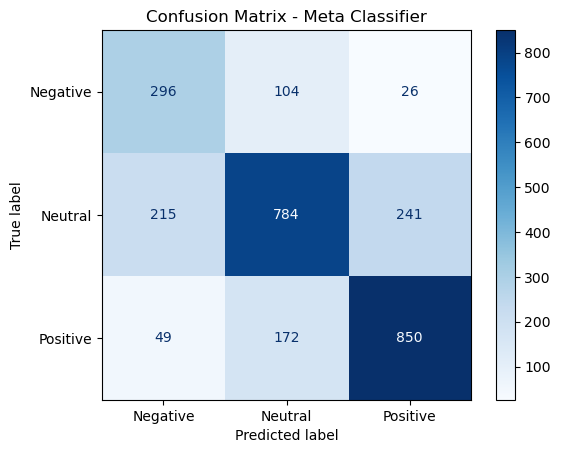

In [113]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Buat confusion matrix
cm = confusion_matrix(y_test, meta_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Neutral", "Positive"])

# Tampilkan
plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - Meta Classifier")
plt.grid(False)
plt.show()


In [114]:
test_df.head()

,text,label,label_text,text_len,vader_pred_default
3056,have you called people yet for Bruno Mars next...,1,neutral,67,neutral
34370,Sundays Lovely Gossip Fabregas to pay his way ...,1,neutral,116,positive
9039,Smashing FIFA atm won the Capital One Cupu002c...,2,positive,118,positive
43024,Boko Haram fighters slit the throats of 10 fis...,0,negative,135,positive
12792,Girls Night OutFriday nightNovember 2nd. Fairf...,1,neutral,143,neutral


In [115]:
# Pastikan X_test adalah daftar teks
texts = test_df["text"].tolist()
true_labels = test_df['label_text'].tolist()
roberta_preds = [roberta_predict_with_confidence(text)[0] for text in texts]
vader_preds = [vader_predict_with_confidence(text)[0] for text in texts]
meta_preds = [meta_predict_label(text) for text in texts]


In [44]:
print(len(texts), len(true_labels), len(roberta_preds), len(meta_preds))

9123 9123 9123 9123


In [55]:
label_map = {0: "negative", 1: "neutral", 2: "positive"}

roberta_preds_str = [label_map[p] for p in roberta_preds]
vader_preds_str = [label_map[p] for p in vader_preds]
meta_preds_str = [label_map[p] for p in meta_preds]


In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

label_order = ["negative", "neutral", "positive"]

roberta_cm = confusion_matrix(true_labels, roberta_preds_str, labels=label_order)
vader_cm = confusion_matrix(true_labels, vader_preds_str, labels=label_order)
meta_cm = confusion_matrix(true_labels, meta_preds_str, labels=label_order)



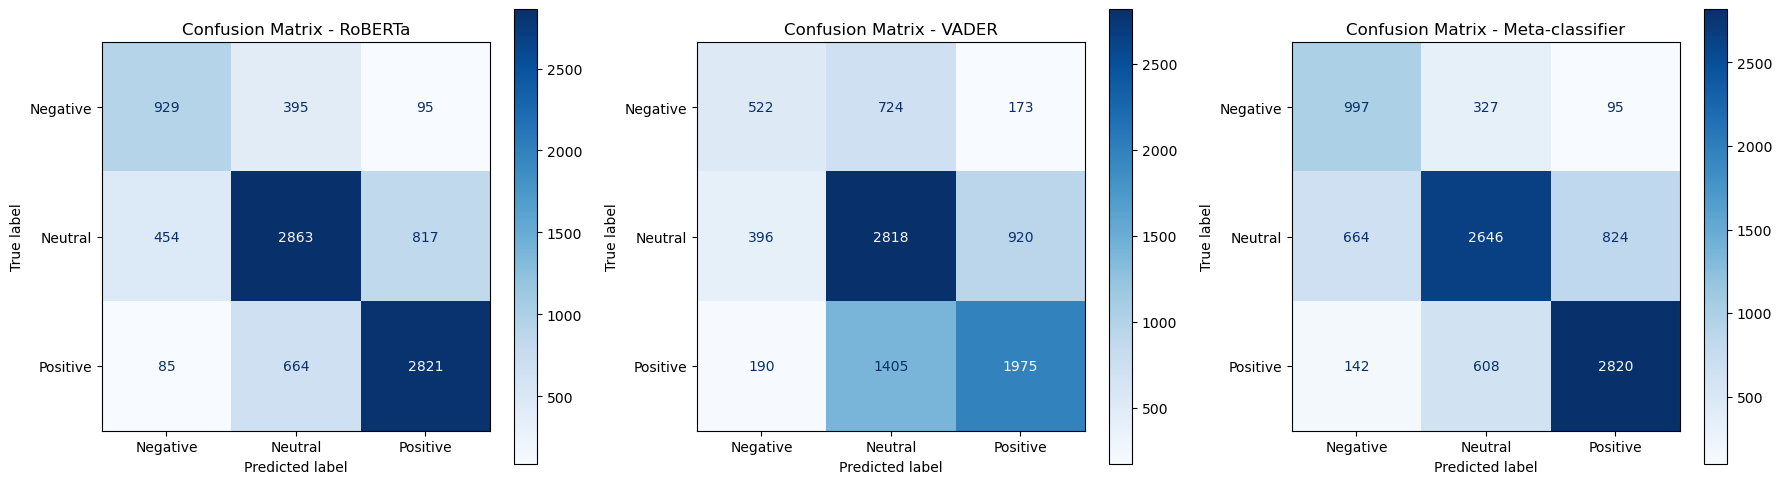

In [47]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
titles = ["RoBERTa", "VADER", "Meta-classifier"]
cms = [roberta_cm, vader_cm, meta_cm]

for ax, cm, title in zip(axs, cms, titles):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Neutral", "Positive"])
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Confusion Matrix - {title}")
    ax.grid(False)

plt.tight_layout()
plt.show()


Meta-classifier memberikan hasil paling seimbang untuk semua kelas, walaupun ada sedikit trade-off pada label negative

RoBERTa unggul di Positive, tetapi terlalu banyak false positive pada Neutral.

VADER masih terlalu netral — cocok untuk baseline tapi tidak untuk high-performance task.

##### 6. analisis Dataset sentiment MU dengan ensemble model

In [132]:
def analyze_sentiment_meta(text):
    r_pred, r_conf = roberta_predict_with_confidence(text)
    v_pred, v_conf = vader_predict_with_confidence(text)

    meta_input = pd.DataFrame([{
        "roberta_pred": r_pred,
        "roberta_conf": r_conf,
        "vader_pred": v_pred,
        "vader_conf": v_conf
    }])

    final_label = meta_model.predict(meta_input)[0]
    label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
    return label_map[final_label]


In [133]:
import re
import emoji
import pandas as pd

def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www.\S+", "", text)                  # Hapus URL
    text = re.sub(r"@\w+", "", text)                             # Hapus mention
    text = re.sub(r"#\w+", "", text)                             # Hapus hashtag
    text = emoji.replace_emoji(text, replace='')                 # Hapus emoji
    text = re.sub(r"[^A-Za-z0-9\s\.\,\!\?]", "", text)           # Hapus simbol aneh
    text = re.sub(r"\s+", " ", text)                             # Hapus spasi berlebih
    return text.strip()

# Contoh pemrosesan seluruh kolom
df = pd.read_csv("tweets-data\MU_public_sentiment.csv")
df["clean_text"] = df["full_text"].apply(clean_text)


In [134]:
df.head()


,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,clean_text
0,1871534310949585151,Tue Dec 24 12:32:05 +0000 2024,14,Jamie O'Hara has claimed Manchester United wer...,1871534310949585151,https://pbs.twimg.com/media/GfkGiDxXUAAEsm7.jpg,NaN,en,NaN,0,6,3,https://x.com/undefined/status/187153431094958...,16902662,NaN,Jamie OHara has claimed Manchester United were...
1,1871527263042424880,Tue Dec 24 12:04:05 +0000 2024,0,1 year of INEOS and Sir Jim and it's just been...,1871527263042424880,NaN,NaN,en,NaN,0,0,0,https://x.com/undefined/status/187152726304242...,106381237,NaN,1 year of INEOS and Sir Jim and its just been ...
2,1871527009383284848,Tue Dec 24 12:03:04 +0000 2024,0,One year ago today Sir Jim Ratcliffe purchased...,1871527009383284848,https://pbs.twimg.com/media/Gfj_5WBWYAA2xgh.jpg,NaN,en,NaN,0,1,0,https://x.com/undefined/status/187152700938328...,1646362020789272576,NaN,One year ago today Sir Jim Ratcliffe purchased...
3,1871524065305039059,Tue Dec 24 11:51:23 +0000 2024,0,One year ago today Sir Jim Ratcliffe purchased...,1871524065305039059,NaN,NaN,en,NaN,0,0,0,https://x.com/undefined/status/187152406530503...,954565172,NaN,One year ago today Sir Jim Ratcliffe purchased...
4,1871521959382827370,Tue Dec 24 11:43:00 +0000 2024,0,Jim Ratcliffe since he bought Manchester Unite...,1871521959382827370,https://pbs.twimg.com/media/Gfj7TXVWwAAFOAK.jpg,NaN,en,NaN,0,0,0,https://x.com/undefined/status/187152195938282...,449218087,NaN,Jim Ratcliffe since he bought Manchester United


In [135]:
df.shape

(3011, 16)

In [136]:
df.columns

Index(['conversation_id_str', 'created_at', 'favorite_count', 'full_text',
       'id_str', 'image_url', 'in_reply_to_screen_name', 'lang', 'location',
       'quote_count', 'reply_count', 'retweet_count', 'tweet_url',
       'user_id_str', 'username', 'clean_text'],
      dtype='object')

In [137]:
# Cek panjang teks (jika ada kolom 'text')
df["text_length"] = df["clean_text"].apply(lambda x: len(str(x)))
df["text_length"].describe()


count    3011.000000
mean      164.887745
std        68.135472
min         9.000000
25%       105.000000
50%       164.000000
75%       227.000000
max       281.000000
Name: text_length, dtype: float64

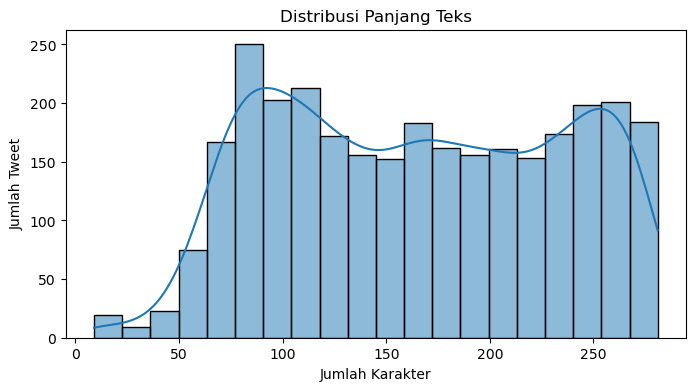

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df["text_length"], bins=20, kde=True)
plt.title("Distribusi Panjang Teks")
plt.xlabel("Jumlah Karakter")
plt.ylabel("Jumlah Tweet")
plt.show()


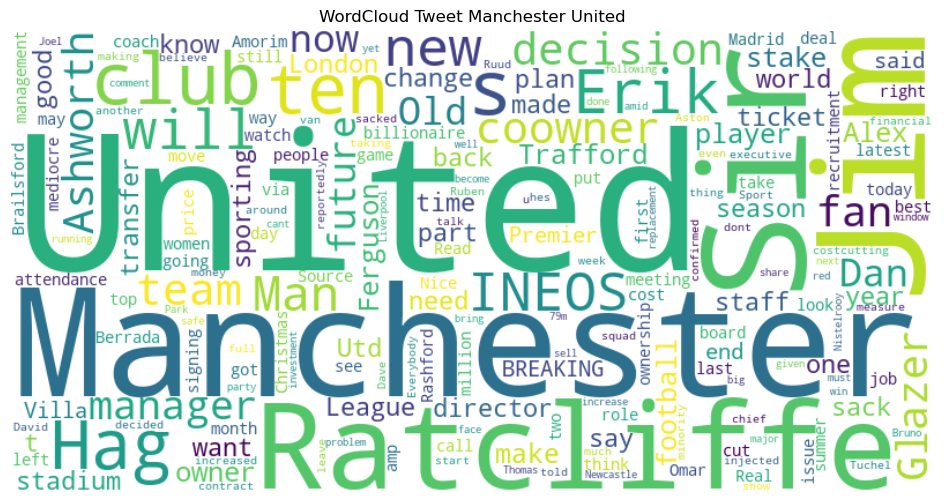

In [139]:
from wordcloud import WordCloud

text_data = ' '.join(df['clean_text'].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white',
                      collocations=False).generate(text_data)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Tweet Manchester United')
plt.show()

In [140]:
from tqdm import tqdm
tqdm.pandas()

df["roberta_sentiment"] = df["clean_text"].progress_apply(lambda x: label_map[roberta_predict_with_confidence(x)[0]])
df["vader_sentiment"] = df["clean_text"].progress_apply(lambda x: label_map[vader_predict_with_confidence(x)[0]])
df["meta_sentiment"] = df["clean_text"].progress_apply(lambda x: label_map[meta_predict_label(x)])

100%|██████████| 3011/3011 [06:40<00:00,  7.51it/s]


In [142]:
# Lihat beberapa hasil prediksi
df[["clean_text", "meta_sentiment", "roberta_sentiment", "vader_sentiment"]].head()


,clean_text,meta_sentiment,roberta_sentiment,vader_sentiment
0,Jamie OHara has claimed Manchester United were...,Negative,Negative,Positive
1,1 year of INEOS and Sir Jim and its just been ...,Negative,Negative,Neutral
2,One year ago today Sir Jim Ratcliffe purchased...,Neutral,Neutral,Positive
3,One year ago today Sir Jim Ratcliffe purchased...,Neutral,Neutral,Positive
4,Jim Ratcliffe since he bought Manchester United,Neutral,Neutral,Positive


C:\Users\User\AppData\Local\Temp\ipykernel_10736\1163697565.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="roberta_sentiment", data=df, order=["Negative", "Neutral", "Positive"], ax=axs[0], palette="Blues")
C:\Users\User\AppData\Local\Temp\ipykernel_10736\1163697565.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="vader_sentiment", data=df, order=["Negative", "Neutral", "Positive"], ax=axs[1], palette="Greens")
C:\Users\User\AppData\Local\Temp\ipykernel_10736\1163697565.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot

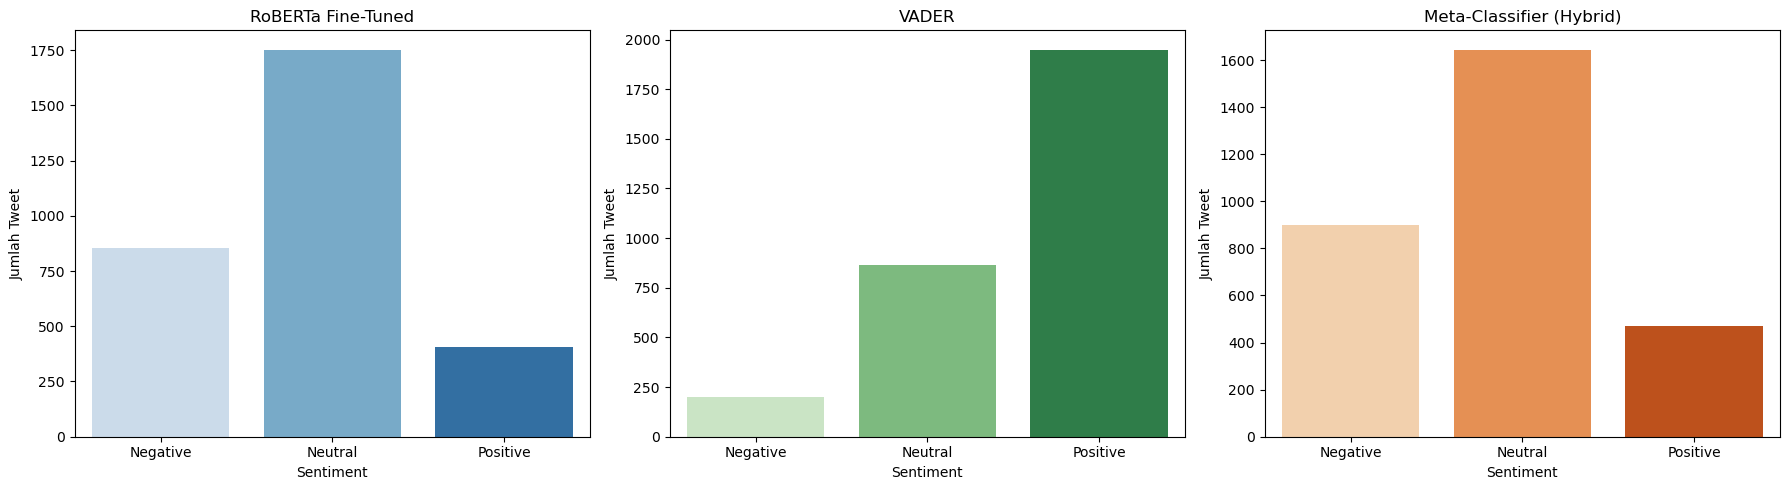

In [144]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x="roberta_sentiment", data=df, order=["Negative", "Neutral", "Positive"], ax=axs[0], palette="Blues")
axs[0].set_title("RoBERTa Fine-Tuned")

sns.countplot(x="vader_sentiment", data=df, order=["Negative", "Neutral", "Positive"], ax=axs[1], palette="Greens")
axs[1].set_title("VADER")

sns.countplot(x="meta_sentiment", data=df, order=["Negative", "Neutral", "Positive"], ax=axs[2], palette="Oranges")
axs[2].set_title("Meta-Classifier (Hybrid)")

for ax in axs:
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("Jumlah Tweet")

plt.tight_layout()
plt.show()



In [148]:
summary = pd.DataFrame({
    "RoBERTa": df["roberta_sentiment"].value_counts(),
    "VADER": df["vader_sentiment"].value_counts(),
    "Hybrid": df["meta_sentiment"].value_counts()
}).reindex(["Negative", "Neutral", "Positive"])

summary


,RoBERTa,VADER,Hybrid
Negative,853,198,898
Neutral,1752,864,1644
Positive,406,1949,469


In [146]:
def plot_wordcloud(text_series, label, color="black"):
    all_text = " ".join(text_series)
    wordcloud = WordCloud(width=800, height=400, background_color=color, colormap='Set2').generate(all_text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud - {label} Tweets")
    plt.show()


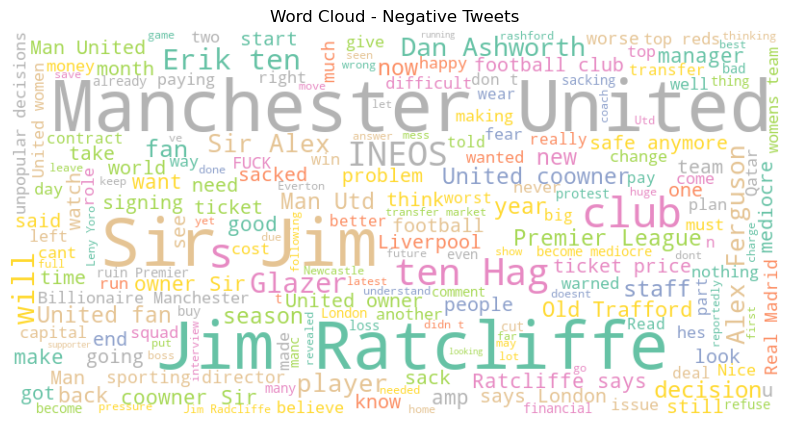

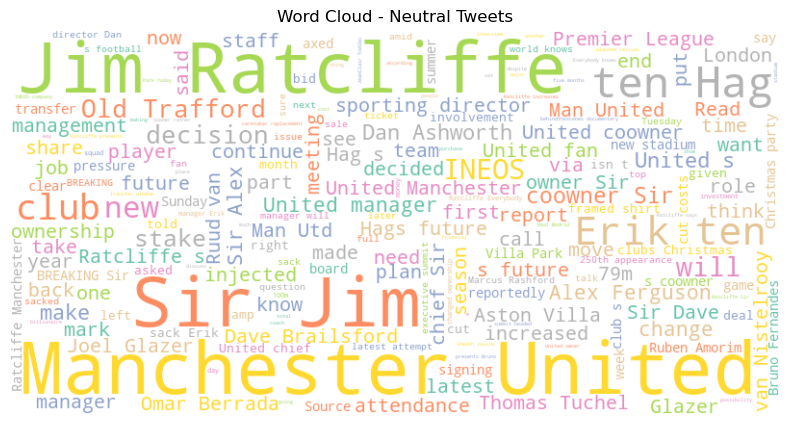

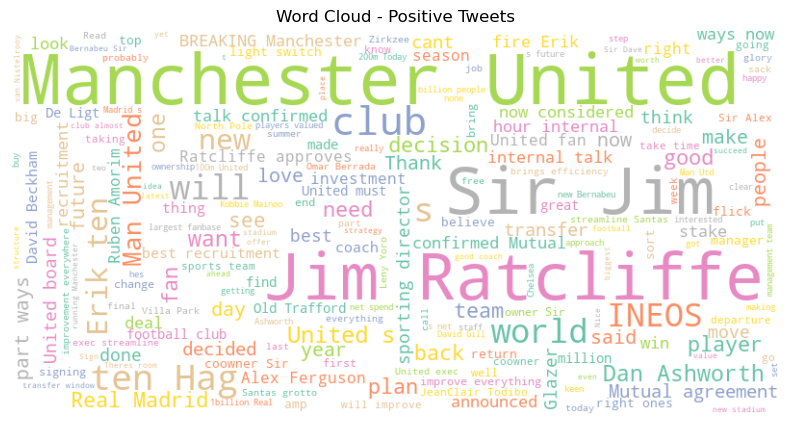

In [147]:
# Filter per sentimen
for label, color in zip(["Negative", "Neutral", "Positive"], ["white", "white", "white"]):
    texts = df[df["meta_sentiment"] == label]["clean_text"]
    plot_wordcloud(texts, label, color=color)

